**Initialization**

The notebook has been tested using MI CPU DEL PORTATIL (i5-1035G1)

In [1]:
import os
import random
from matplotlib import pyplot as plt
import cv2

import numpy as np
import pandas as pd

import snntorch as snn
import torch

# Para crear dataloaders personalizados con TorchVision

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Para medir consumo energético

from codecarbon import EmissionsTracker


**Creating train set (NEW, para SNNTorch)**

In [2]:
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("../data_snn_flat/train/", transform=transform_train)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


print("Total imágenes entrenamiento:", len(train_dataset))

Total imágenes entrenamiento: 155015


In [3]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

torch.Size([64, 3, 32, 32]) torch.Size([64])


**Creating the test set (NEW, para SNNTorch)**

In [4]:
transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder("../data_snn_flat/test/", transform=transform_test)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Total imágenes test:", len(test_dataset))


Total imágenes test: 30000


In [5]:
print(len(train_dataset), len(test_dataset))
print(train_dataset.classes)

155015 30000
['AI', 'human']


**Mostramos los datos del dataset para ver que las imagenes están procesadas correctamente (y por curiosidad)**

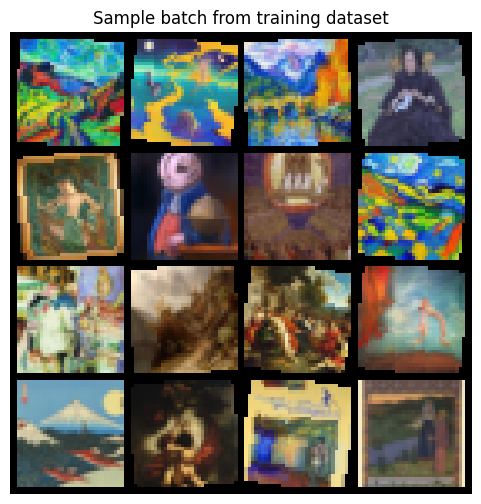

Labels: [0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1]
155015 30000


['AI', 'human']

In [6]:
import matplotlib.pyplot as plt
import torchvision

data_iter = iter(train_loader)
images, labels = next(data_iter)

# Crea una cuadrícula automáticamente
img_grid = torchvision.utils.make_grid(images[:16], nrow=4, padding=2)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(6, 6))
plt.imshow(img_grid)
plt.title("Sample batch from training dataset")
plt.axis("off")
plt.show()

print("Labels:", labels[:16].tolist())

#### Ojito, esto no funciona de primeras, tienes que crear el Dataloader de entrenamiento,
#### y este se crea más tarde, pero en el original iba aquí. Si quieres usarlo crea el dataloader
#### más abajo.
####     0 = AI           1 = humano

print(len(train_dataset), len(test_dataset))

train_dataset.classes

**Building the neural network**

**Training neural network (NEW, para SNNTorch)**

In [7]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import itertools

In [8]:
# pass data into the network, sum the spikes over time
# and compare the neuron with the highest number of spikes
# with the target

def print_batch_accuracy(data, targets, train=False):
    output, _ = net(data)
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())

    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer(
    data, targets, epoch,
    counter, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

**Añadimos ahora el bucle de entrenamiento**

In [9]:
num_outputs = len(train_dataset.classes)
print(len(train_dataset.classes))

2


In [10]:
import torch.nn as nn
import torch.nn.functional as F
import torch, torch.nn as nn
import snntorch as snn
from snntorch import surrogate

beta = 0.9  # neuron decay rate
spike_grad = surrogate.fast_sigmoid() # fast sigmoid surrogate gradient
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5)  # 3 de entrada, 16 salida (filtros), tamaño del filtro
        # Pasamos de 32 * 32 * 3  -->  32-5+1 * 32-5+1 * 16 (canales de salida) = 28 * 28 * 16
        self.pool = nn.MaxPool2d(2, 2)  # Aplicamos max pooling con un filtro de 2x2
        # Pasamos de 28 * 28 * 16  -->  28/2 * 28/2 * 16 = 14 * 14 * 16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5) # Lo mismo que el primero solo que la entrada es 16, porque en la anterior convolucion teniamos 16 filtros, y ahora la salida es de 32 canales
        # Pasamos de 14 * 14 * 16  -->  14-5+1 * 14-5+1 * 16 = 10 * 10 * 32
        # En el forward ahora aplicamos el pool otra vez, así que tenemos 5 * 5 * 32
        self.fc1 = nn.Linear(5 * 5 * 32, 120) # Aplanamos con una fully conected de la matriz que tenemos de 5*5*32 a 120 neuronas
        self.fc2 = nn.Linear(120, 60) # Aplanamos de nuevo de 120 neuronas a 60 neuronas
        self.fc3 = nn.Linear(60, num_classes) # Finalmente aplanamos las 60 neuronas en las clases que queremos sacar, en nuestro caso 2
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # Para hacer la fc debemos aplanarla antes
        x = x.view(-1, 32 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = SimpleCNN().to(device)

In [21]:
from collections import Counter
# Como la cantidad de imágenes IA está descompensado con respecto a las humanas, vamos
# a darle más peso a los errores en la clase humana
counts = Counter(train_dataset.targets)
class_counts = torch.tensor([counts[i] for i in range(len(train_dataset.classes))], dtype=torch.float)

print("Clases:", train_dataset.classes)
print("Conteo:", class_counts)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 2
class_weights = class_weights.to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

Clases: ['AI', 'human']
Conteo: tensor([105015.,  50000.])


In [ ]:
import torch.optim as optim
from codecarbon import EmissionsTracker


def train():
    net = SimpleCNN(num_classes=2).to(device)

    class_counts = torch.tensor([155015, 30000])
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * 2
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(net.parameters(), lr=0.001)


    # Metricas por batch
    loss_hist = []
    test_loss_hist = []
    val_accuracy_hist = []

    # Metricas por epoch
    epoch_loss_hist = []
    epoch_test_loss_hist = []
    epoch_acc_hist = []


    num_epochs = 10

    # optimizer.load_state_dict(torch.load('./saved_models/optimizador_CNN.pth'))

    tracker = EmissionsTracker(
        log_level="error",
        save_to_file=True,
        output_dir="../Consumo",
        output_file="emissions_cnn.csv",
        measure_power_secs=1
    )
    tracker.start()

    for epoch in range(num_epochs):
            
        # Train    

        net.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Métrica de nivel batch (train loss)
            loss_hist.append(loss.item())
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if i % 25 == 0:
                print(f"Epoch {epoch}, Iteration {i} - Loss: {running_loss/(i+1):.4f} Accuracy: {100*correct/total:.2f}%")

        # TEST

        net.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                # Métricas de nivel batch (test loss y accuracy)
                test_loss_hist.append(loss.item())
                batch_correct = (torch.max(outputs.data, 1)[1] == labels).sum().item()
                batch_acc = 100 * batch_correct / labels.size(0)
                val_accuracy_hist.append(batch_acc)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        avg_test_loss = test_loss / len(test_loader)
        test_accuracy = 100 * correct_test / total_test

        # Métrica de nivel epoch (test loss)
        epoch_test_loss_hist.append(avg_test_loss)

        print(f"[TEST] Epoch {epoch} - Loss: {avg_test_loss:.4f} Acc: {test_accuracy:.2f}%")



        # Métrica de nivel epoch (train loss y accuracy)
        epoch_loss_hist.append(running_loss / len(train_loader))
        epoch_acc_hist.append(100 * correct / total)
        # Terminamos la medicion

    emissions = tracker.stop()
    print(f"Emisiones de CO₂ (kg): {emissions}")     

    torch.save({
        'epoch': epoch,
        'model_state_dict': net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_hist': loss_hist,
        'test_loss_hist': test_loss_hist,
        'val_accuracy_hist': val_accuracy_hist,
        'epoch_loss_hist': epoch_loss_hist,
        'epoch_test_loss_hist': epoch_test_loss_hist,
        'epoch_acc_hist': epoch_acc_hist,
    }, '../Modelos_Guardados/checkpoint_cnn.pth')

    print("Entrenamiento terminado")

train()

[codecarbon WARNING @ 06:36:16] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 0, Iteration 0 - Loss: 0.7130 Accuracy: 65.62%
Epoch 0, Iteration 25 - Loss: 0.6231 Accuracy: 35.64%
Epoch 0, Iteration 50 - Loss: 0.6119 Accuracy: 33.64%
Epoch 0, Iteration 75 - Loss: 0.5939 Accuracy: 35.26%
Epoch 0, Iteration 100 - Loss: 0.5737 Accuracy: 39.05%
Epoch 0, Iteration 125 - Loss: 0.5504 Accuracy: 43.29%
Epoch 0, Iteration 150 - Loss: 0.5302 Accuracy: 46.81%
Epoch 0, Iteration 175 - Loss: 0.5208 Accuracy: 49.14%
Epoch 0, Iteration 200 - Loss: 0.5086 Accuracy: 51.26%
Epoch 0, Iteration 225 - Loss: 0.5020 Accuracy: 52.96%
Epoch 0, Iteration 250 - Loss: 0.4934 Accuracy: 54.42%
Epoch 0, Iteration 275 - Loss: 0.4855 Accuracy: 55.50%
Epoch 0, Iteration 300 - Loss: 0.4773 Accuracy: 56.60%
Epoch 0, Iteration 325 - Loss: 0.4750 Accuracy: 57.21%
Epoch 0, Iteration 350 - Loss: 0.4720 Accuracy: 57.93%
Epoch 0, Iteration 375 - Loss: 0.4669 Accuracy: 58.76%
Epoch 0, Iteration 400 - Loss: 0.4634 Accuracy: 59.61%
Epoch 0, Iteration 425 - Loss: 0.4602 Accuracy: 60.24%
Epoch 0, Iterat

In [ ]:
import torch.optim as optim
from codecarbon import EmissionsTracker

num_epochs = 10

net = SimpleCNN(num_classes=2).to(device)

optimizer = optim.Adam(net.parameters(), lr=0.001)

# Metricas por batch
loss_hist = []
test_loss_hist = []
val_accuracy_hist = []

# Metricas por epoch
epoch_loss_hist = []
epoch_test_loss_hist = []
epoch_acc_hist = []

start_epoch = 0

# Cargamos el checkpoint si existe, para reanudar el entrenamiento
import os
checkpoint_path = '../Modelos_Guardados/checkpoint_cnn.pth'

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    net.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    loss_hist = checkpoint['loss_hist']
    test_loss_hist = checkpoint['test_loss_hist']
    val_accuracy_hist = checkpoint['val_accuracy_hist']
    epoch_loss_hist = checkpoint['epoch_loss_hist']
    epoch_test_loss_hist = checkpoint['epoch_test_loss_hist']
    epoch_acc_hist = checkpoint['epoch_acc_hist']

    start_epoch = checkpoint['epoch'] + 1
    print(f"Checkpoint encontrado. Reanudando desde epoch {start_epoch}.")
else:
    print("No se encontró checkpoint previo. Empezando desde epoch 0.")


def train():

    tracker = EmissionsTracker(
        log_level="error",
        save_to_file=True,
        output_dir="../Consumo",
        output_file="emissions_cnn.csv",
        measure_power_secs=1
    )
    tracker.start()

    for epoch in range(start_epoch, num_epochs):

        # Train    

        net.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Métrica de nivel batch (train loss)
            loss_hist.append(loss.item())
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if i % 25 == 0:
                print(f"Epoch {epoch}, Iteration {i} - Loss: {running_loss/(i+1):.4f} Accuracy: {100*correct/total:.2f}%")

        # TEST

        net.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                # Métricas de nivel batch (test loss y accuracy)
                test_loss_hist.append(loss.item())
                batch_correct = (torch.max(outputs.data, 1)[1] == labels).sum().item()
                batch_acc = 100 * batch_correct / labels.size(0)
                val_accuracy_hist.append(batch_acc)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        avg_test_loss = test_loss / len(test_loader)
        test_accuracy = 100 * correct_test / total_test

        # Métrica de nivel epoch (test loss)
        epoch_test_loss_hist.append(avg_test_loss)

        print(f"[TEST] Epoch {epoch} - Loss: {avg_test_loss:.4f} Acc: {test_accuracy:.2f}%")

        # Métrica de nivel epoch (train loss y accuracy)
        epoch_loss_hist.append(running_loss / len(train_loader))
        epoch_acc_hist.append(100 * correct / total)

    emissions = tracker.stop()
    print(f"Emisiones de CO₂ (kg): {emissions}")     

    print("Entrenamiento terminado")

train()

[codecarbon WARNING @ 21:02:35] Multiple instances of codecarbon are allowed to run at the same time.


No se encontró checkpoint previo. Empezando desde epoch 0.
Epoch 0, Iteration 0 - Loss: 0.6715 Accuracy: 81.25%


KeyboardInterrupt: 

In [14]:
# Cargamos el checkpoint si existe, para reanudar el entrenamiento
import os
checkpoint_path = '../Modelos_Guardados/checkpoint_cnn.pth'
optimizer = optim.Adam(net.parameters(), lr=0.001)


if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    net.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    loss_hist = checkpoint['loss_hist']
    test_loss_hist = checkpoint['test_loss_hist']
    val_accuracy_hist = checkpoint['val_accuracy_hist']
    epoch_loss_hist = checkpoint['epoch_loss_hist']
    epoch_test_loss_hist = checkpoint['epoch_test_loss_hist']
    epoch_acc_hist = checkpoint['epoch_acc_hist']

    start_epoch = checkpoint['epoch'] + 1
    print(f"Checkpoint encontrado. Reanudando desde epoch {start_epoch}.")
else:
    print("No se encontró checkpoint previo. Empezando desde epoch 0.")

Checkpoint encontrado. Reanudando desde epoch 10.


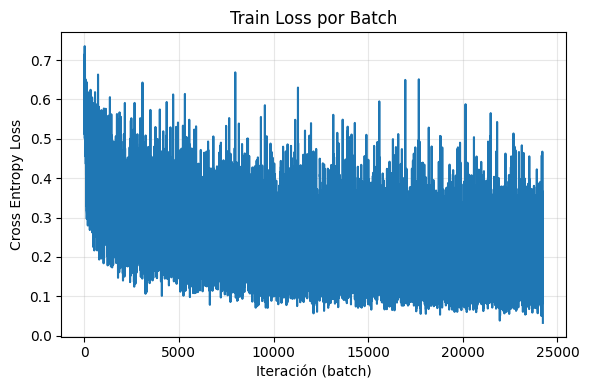

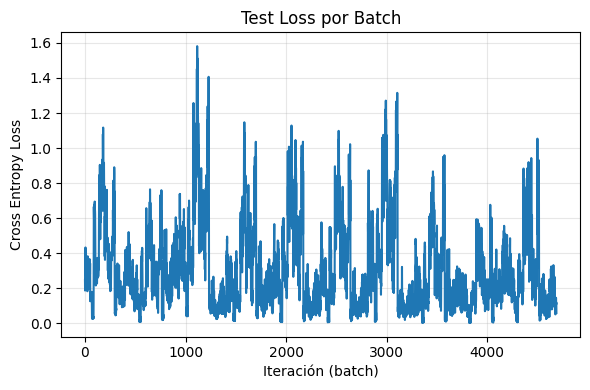

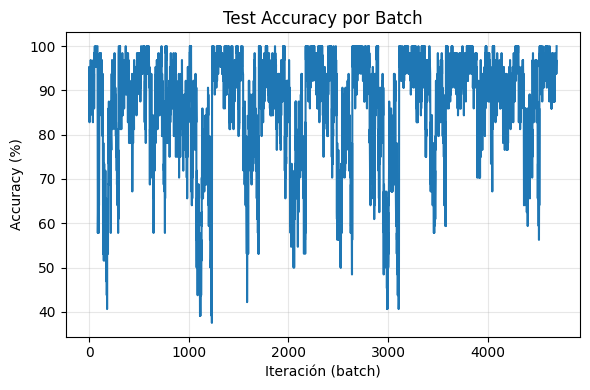

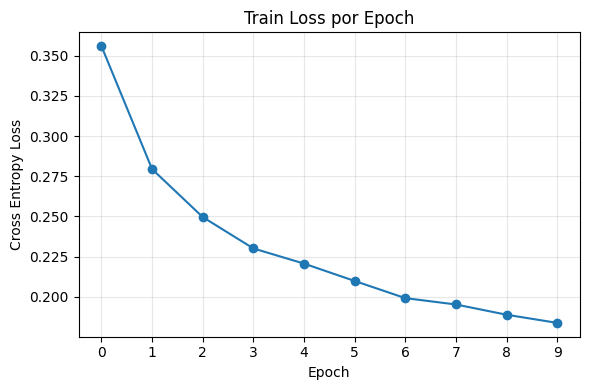

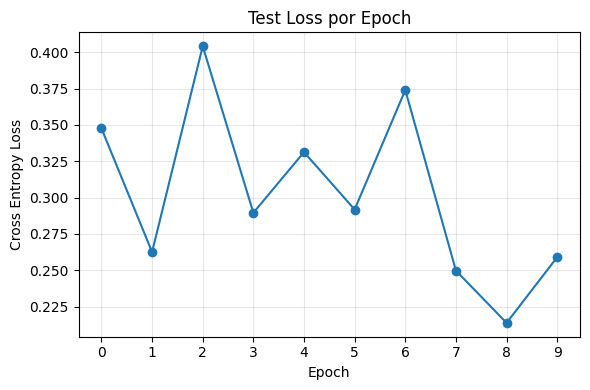

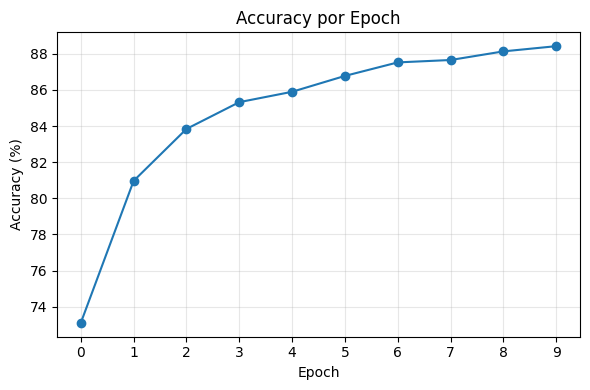

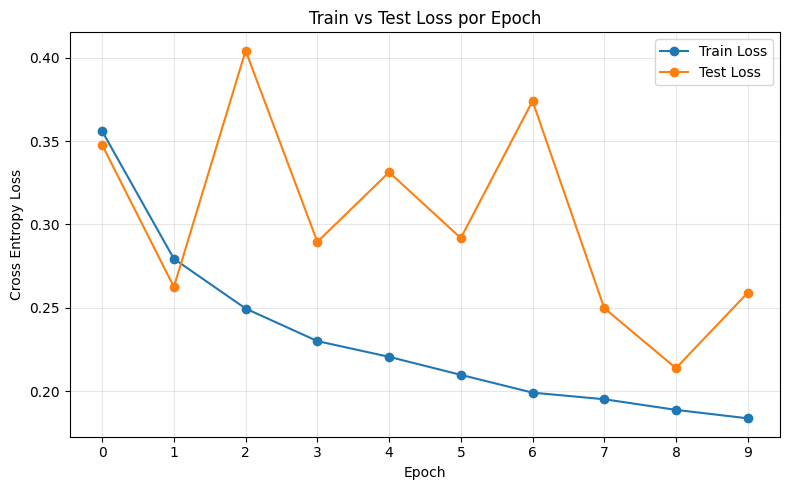

In [18]:
import matplotlib.pyplot as plt

# GRÁFICAS NIVEL BATCH

import matplotlib.pyplot as plt

# Train Loss por batch
plt.figure(figsize=(6, 4))
plt.plot(loss_hist)
plt.title("Train Loss por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Cross Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN/train_loss_batch.png", dpi=150)
plt.show()


# Test Loss por batch
plt.figure(figsize=(6, 4))
plt.plot(test_loss_hist)
plt.title("Test Loss por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Cross Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN/test_loss_batch.png", dpi=150)
plt.show()


# Test Accuracy por batch
plt.figure(figsize=(6, 4))
plt.plot(val_accuracy_hist)
plt.title("Test Accuracy por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN/test_accuracy_batch.png", dpi=150)
plt.show()

# GRÁFICAS NIVEL EPOCH

epochs_range = range(len(epoch_loss_hist))

# Train Loss por epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, epoch_loss_hist, marker='o')
plt.title("Train Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN/train_loss_epoch.png", dpi=150)
plt.show()


# Test Loss por epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, epoch_test_loss_hist, marker='o')
plt.title("Test Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN/test_loss_epoch.png", dpi=150)
plt.show()


# Accuracy por epoch
epochs_range_acc = range(len(epoch_acc_hist))

plt.figure(figsize=(6, 4))
plt.plot(epochs_range_acc, epoch_acc_hist, marker='o')
plt.title("Accuracy por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs_range_acc)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN/accuracy_epoch.png", dpi=150)
plt.show()

# COMPARATIVA TRAIN vs TEST LOSS POR EPOCH (superpuesto)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, epoch_loss_hist, marker='o', label="Train Loss")
plt.plot(epochs_range, epoch_test_loss_hist, marker='o', label="Test Loss")
plt.title("Train vs Test Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/CNN/train_vs_test_loss.png", dpi=150)
plt.show()

In [ ]:
import torch
from codecarbon import EmissionsTracker

def evaluate_cnn_energy(model, test_loader, device):

    model.eval()  # modo evaluación

    correct = 0
    total = 0

    tracker = EmissionsTracker(
        log_level="error",
        output_file="emissions_cnn_inference.csv",
        measure_power_secs=1
    )

    tracker.start()

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    emissions = tracker.stop()

    accuracy = 100 * correct / total

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Energía consumida (kg CO₂ aprox): {emissions}")

    return accuracy, emissions

In [17]:
model = SimpleCNN(num_classes=2).to(device)
# model.load_state_dict(torch.load("ruta_modelo.pth"))

evaluate_cnn_energy(model, test_loader, device)

Accuracy: 66.31%
Energía consumida (kg CO₂ aprox): 5.2183134570002384e-05


(66.31333333333333, 5.2183134570002384e-05)

In [16]:
net.eval()
running_val_loss = 0.0
test_loss_hist = []

# Descomentar para usar el modelo guardado en pth

# net = torch.load('./saved_models/modelo_entrenado_CNN.pth', weights_only=False)
# criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        # labels = labels.float().unsqueeze(1)
        labels = labels.to(device)

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(test_loader)
        test_loss_hist.append(avg_val_loss)

print(
    f"Epoch {epoch} | "
    f"Train Loss: {avg_train_loss:.4f} | "
    f"Val Loss: {avg_val_loss:.4f}"
)

NameError: name 'criterion' is not defined

In [ ]:
from PIL import Image
from torchvision import transforms

# Descomentar para cargar modelo previamente entrenado

# net = torch.load('./saved_models/modelo_entrenado_CNN.pth', weights_only=False)

net.eval()

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# Carga y preprocesa la imagen
img_path = "/home/rootcgb/Documentos/AI-Artbench/evalPropio/van.jpg"  # pon aquí la ruta real
img = Image.open(img_path).convert('RGB')
img = transform(img).unsqueeze(0).to(device)  # añadir batch dim y pasar a dispositivo

with torch.no_grad():
    outputs = net(img)
    _, predicted_class = torch.max(outputs, 1)

if (predicted_class.item() == 0):
    salida = "IA"
else:
    salida = "Humano"
print(f"La imagen es de la clase: {salida}")

La imagen es de la clase: Humano


**Evaluating the network**

In [1]:
#predictions = net.predict(test_dataset)
#predictions
def predict_dataset(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device)
            
            # Forward pass
            spk_rec, mem_rec = model(data)
            
            # Rate coding: suma de spikes en el tiempo
            spike_counts = spk_rec.sum(dim=0)  # (batch_size, num_classes)
            
            # Predicción: neurona con más spikes
            _, predicted = spike_counts.max(1)
            
            all_predictions.append(predicted.cpu())
            all_targets.append(targets)
    
    # Concatenar todas las predicciones
    predictions = torch.cat(all_predictions)
    targets = torch.cat(all_targets)
    
    return predictions, targets

# USO:
predictions, true_labels = predict_dataset(net, test_loader, device)
print(f"Predicciones: {predictions[:10]}")
print(f"Labels reales: {true_labels[:10]}")

NameError: name 'net' is not defined